# Лабораторная работа № 2

## Визуальный анализ данных

**Цель работы:** изучить программные средства, используемые для визуализации наборов данных.

Выполним визуальный анализ набора данных `Employee.csv`. Набор содержит данные о сотрудниках компании (образование, год трудоустройства, город, уровень оплаты, возраст, пол, нахождение в резерве, опыт в текущей области, увольнение). Набор данных подходит для анализа факторов, влияющих на текучесть кадров. Набор данных включает следующие атрибуты:

- **Education** – уровень образования (Bachelors, Masters, PHD);
- **JoiningYear** – год трудоустройства;
- **City** – город (Bangalore, Pune, New Delhi);
- **PaymentTier** – уровень оплаты (1, 2, 3);
- **Age** – возраст (лет);
- **Gender** – пол (Male, Female);
- **EverBenched** – находился ли в резерве (No/Yes);
- **ExperienceInCurrentDomain** – опыт в текущей области (лет);
- **LeaveOrNot** – уволился или нет (0 – нет, 1 – да).

## 0. Импортируем необходимые библиотеки

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

## 1. Загружаем набор данных Employee.csv и помещаем его в объект DataFrame

In [2]:
df = pd.read_csv('Employee.csv')
df.head()

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
1,Bachelors,2013,Pune,1,28,Female,No,3,1
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1


## 2. Выведем 5 первых и 5 последних строк

In [30]:
df.head(5)

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot,experience_to_age_ratio
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0,0.000000
1,Bachelors,2013,Pune,1,28,Female,No,3,1,0.107143
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0,0.052632
3,Masters,2016,Bangalore,3,27,Male,No,5,1,0.185185
4,Masters,2017,Pune,3,24,Male,Yes,2,1,0.083333


In [31]:
df.tail(5)

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot,experience_to_age_ratio
4648,Bachelors,2013,Bangalore,3,26,Female,No,4,0,0.153846
4649,Masters,2013,Pune,2,37,Male,No,2,1,0.054054
4650,Masters,2018,New Delhi,3,27,Male,No,5,1,0.185185
4651,Bachelors,2012,Bangalore,3,30,Male,Yes,2,0,0.066667
4652,Bachelors,2015,Bangalore,3,33,Male,Yes,4,0,0.121212


## 3. Получим общую информацию о данных (типы, количество ненулевых значений).

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Education                  4653 non-null   object 
 1   JoiningYear                4653 non-null   int64  
 2   City                       4653 non-null   object 
 3   PaymentTier                4653 non-null   int64  
 4   Age                        4653 non-null   int64  
 5   Gender                     4653 non-null   object 
 6   EverBenched                4653 non-null   object 
 7   ExperienceInCurrentDomain  4653 non-null   int64  
 8   LeaveOrNot                 4653 non-null   int64  
 9   experience_to_age_ratio    4653 non-null   float64
dtypes: float64(1), int64(5), object(4)
memory usage: 363.6+ KB


## 4. Выведите с помощью describe() основные статистические показатели для всех числовых признаков

In [4]:
df.describe()

,JoiningYear,PaymentTier,Age,ExperienceInCurrentDomain,LeaveOrNot
count,4653.000000,4653.000000,4653.000000,4653.000000,4653.000000
mean,2015.062970,2.698259,29.393295,2.905652,0.343864
std,1.863377,0.561435,4.826087,1.558240,0.475047
min,2012.000000,1.000000,22.000000,0.000000,0.000000
25%,2013.000000,3.000000,26.000000,2.000000,0.000000
50%,2015.000000,3.000000,28.000000,3.000000,0.000000
75%,2017.000000,3.000000,32.000000,4.000000,1.000000
max,2018.000000,3.000000,41.000000,7.000000,1.000000


## 5. Гистограммы распределения количественных признаков

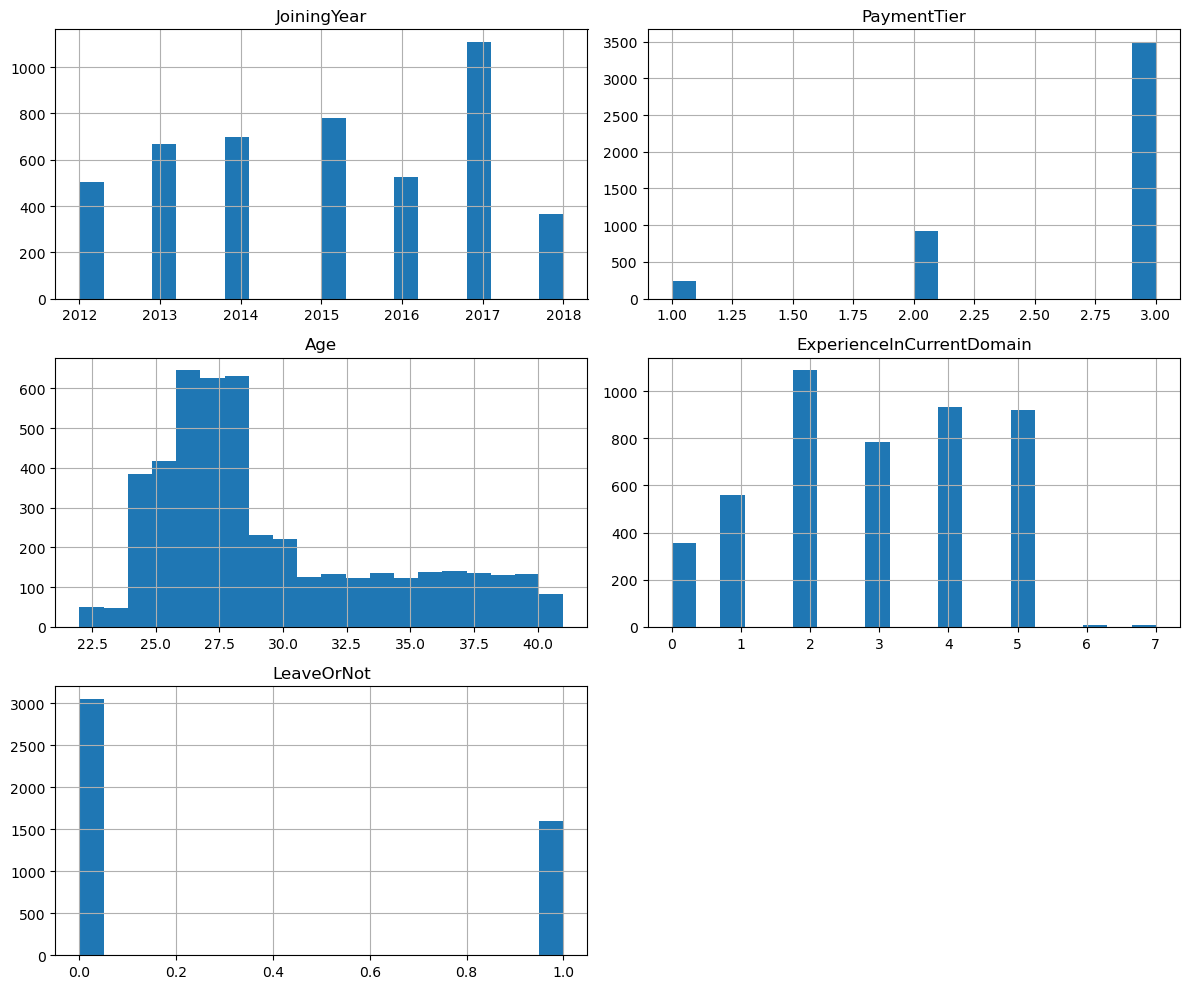

In [5]:
df.hist(figsize=(12, 10), bins=20)
plt.tight_layout()
plt.show()

## 6. Ящик с усами для возраста

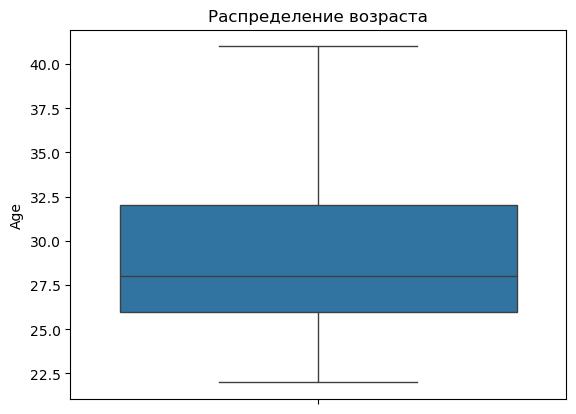

In [6]:
sns.boxplot(y=df['Age'])
plt.title('Распределение возраста')
plt.show()

## 7. Визуализация категориальных признаков

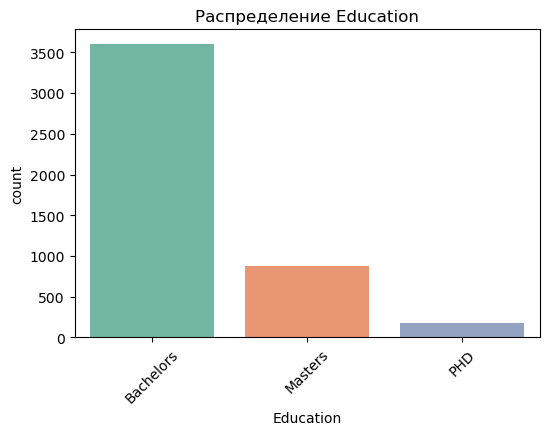

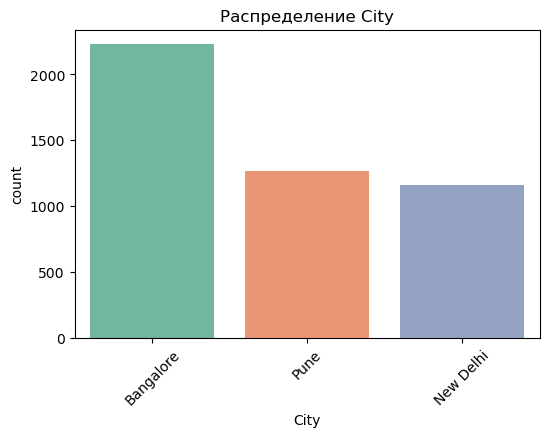

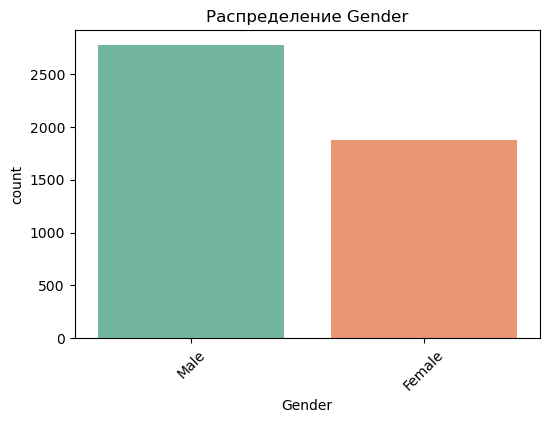

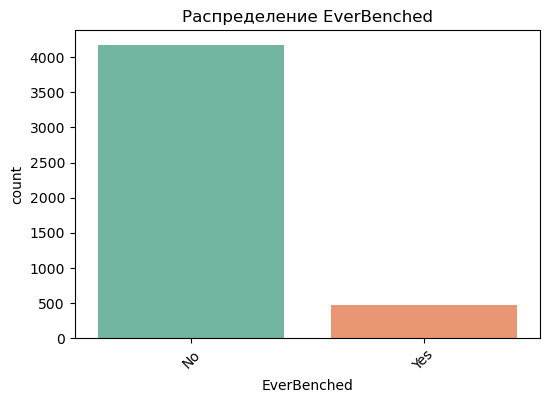

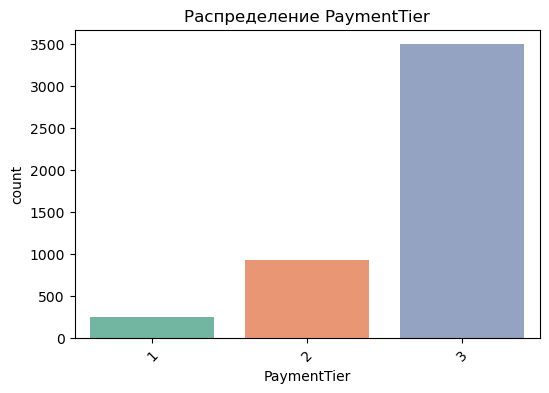

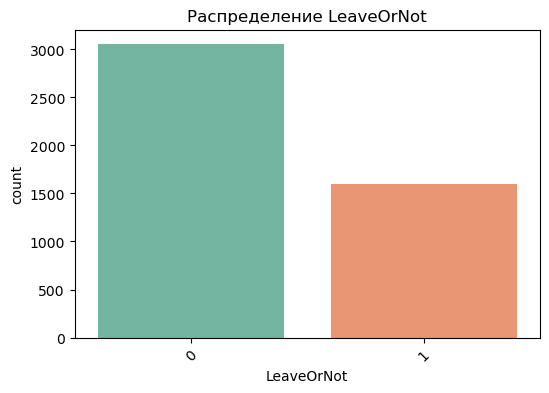

In [7]:
for col in ['Education', 'City', 'Gender', 'EverBenched', 'PaymentTier', 'LeaveOrNot']:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col, hue=col, palette='Set2', legend=False)
    plt.title(f'Распределение {col}')
    plt.xticks(rotation=45)
    plt.show()

## 8. Диаграмма рассеяния: опыт vs возраст

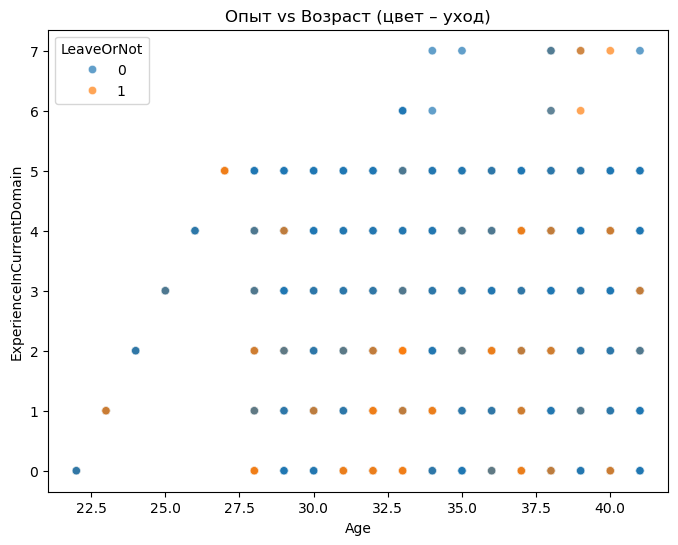

In [8]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Age', y='ExperienceInCurrentDomain', hue='LeaveOrNot', alpha=0.7)
plt.title('Опыт vs Возраст (цвет – уход)')
plt.show()

## 9. Парные графики (pairplot)

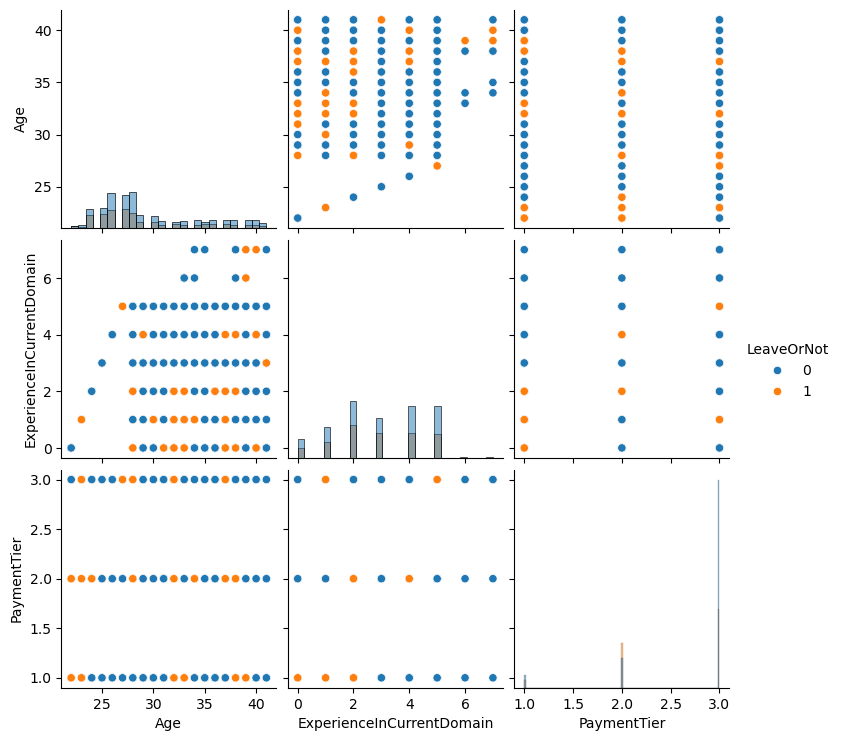

In [9]:
sns.pairplot(df[['Age', 'ExperienceInCurrentDomain', 'PaymentTier', 'LeaveOrNot']], hue='LeaveOrNot', diag_kind='hist')
plt.show()

## 10. Тепловая карта корреляции

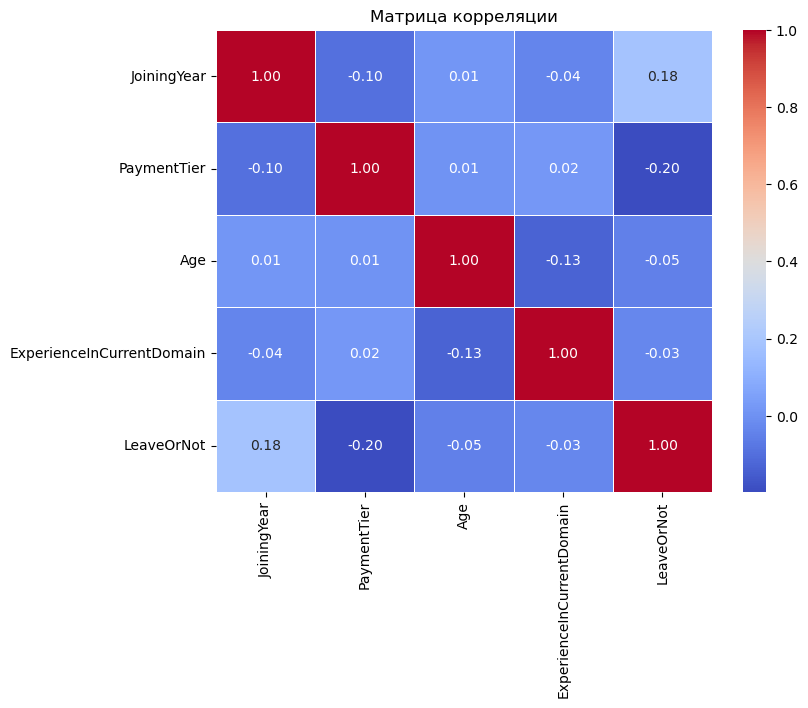

In [10]:
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Матрица корреляции')
plt.show()

## 11. Stripplot: возраст по городам и полу

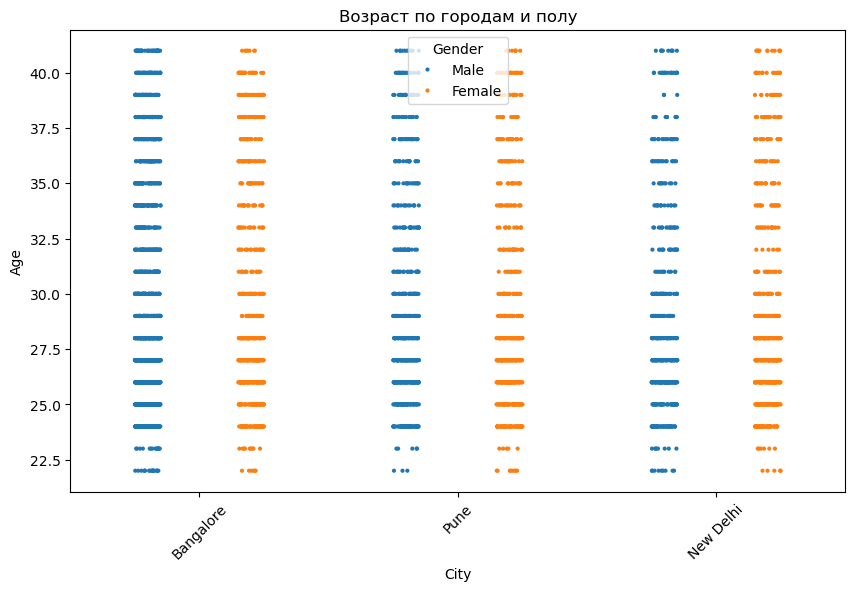

In [11]:
plt.figure(figsize=(10,6))
sns.stripplot(data=df, x='City', y='Age', hue='Gender', dodge=True, jitter=True, size=3)
plt.title('Возраст по городам и полу')
plt.xticks(rotation=45)
plt.show()

## 12. Точечный график: средний опыт по образованию

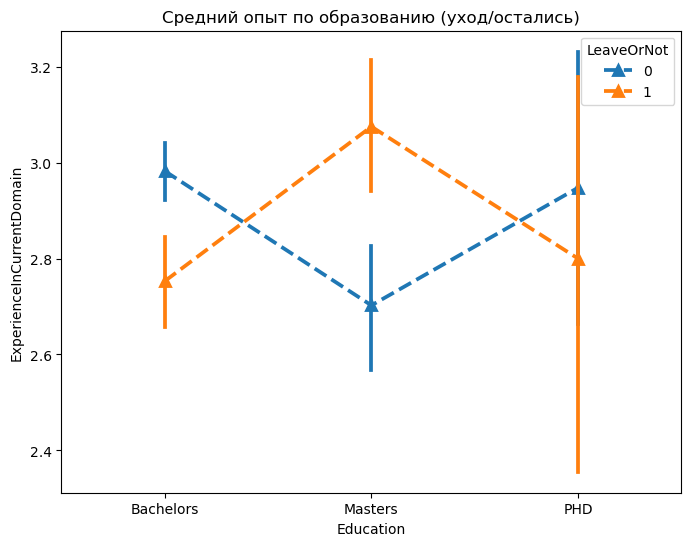

In [12]:
plt.figure(figsize=(8,6))
sns.pointplot(data=df, x='Education', y='ExperienceInCurrentDomain', hue='LeaveOrNot', markers='^', linestyles='--')
plt.title('Средний опыт по образованию (уход/остались)')
plt.show()

## 13. FacetGrid: распределение опыта по городам

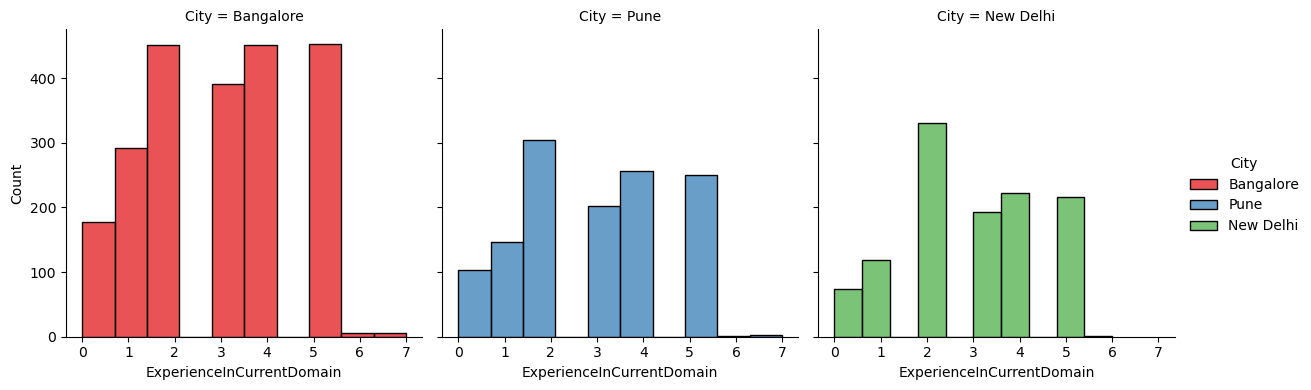

In [13]:
g = sns.FacetGrid(df, col='City', height=4, hue='City', palette='Set1')
g.map(sns.histplot, 'ExperienceInCurrentDomain', bins=10)
g.add_legend()
plt.show()

## 14. Создание нового признака

In [14]:
df['experience_to_age_ratio'] = df['ExperienceInCurrentDomain'] / df['Age']
df.head()

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot,experience_to_age_ratio
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0,0.000000
1,Bachelors,2013,Pune,1,28,Female,No,3,1,0.107143
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0,0.052632
3,Masters,2016,Bangalore,3,27,Male,No,5,1,0.185185
4,Masters,2017,Pune,3,24,Male,Yes,2,1,0.083333


## 15. Сохранение результата

In [15]:
df.to_csv('result.csv', index=False)
print("Файл result.csv сохранён")

Файл result.csv сохранён


## Выводы по визуальному анализу

На основе построенных графиков можно сделать следующие выводы:
- Гистограммы показывают, что возраст сотрудников в основном сосредоточен в диапазоне 22–35 лет, опыт в текущей области – от 0 до 7 лет.
- Ящик с усами для возраста выявил выбросы в старших возрастных группах.
- Столбчатые диаграммы для категориальных признаков показывают, что в выборке преобладают мужчины, сотрудники с образованием Bachelors, а также сотрудники из города Bangalore.
- Диаграмма рассеяния «опыт vs возраст» показывает ожидаемую положительную корреляцию: с возрастом опыт растёт.
- Парные графики не выявили сильных нелинейных зависимостей, но подтвердили умеренную связь возраста и опыта.
- Тепловая карта корреляции показывает, что `LeaveOrNot` слабо коррелирует с `Age` и `ExperienceInCurrentDomain`, но заметно – с `PaymentTier`.
- Stripplot и pointplot демонстрируют, что в городе Pune самый высокий средний возраст сотрудников, а образование Masters связано с большим опытом.
- Добавленный признак `experience_to_age_ratio` позволит в дальнейшем анализировать эффективность сотрудников относительно их возраста.